<a href="https://colab.research.google.com/github/shifanqureshi018-dotcom/excel-projects-data-analytics/blob/main/mpg_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np

In [ ]:
import pandas as pd

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/auto-mpg.csv")

In [ ]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [ ]:
df.tail()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
393,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79,2625,18.6,82,1,ford ranger
397,31.0,4,119.0,82,2720,19.4,82,1,chevy s-10


In [ ]:
df.describe()

,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


In [ ]:
df.describe(include=["object"])

,horsepower,car name
count,398,398
unique,94,305
top,150,ford pinto
freq,22,6


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [ ]:
df.shape

(398, 9)

In [ ]:
df.isnull().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model year,0
origin,0
car name,0


In [ ]:
df.replace("?", np.nan, inplace=True)
df.dropna(subset=['horsepower'], inplace=True)

In [ ]:
df.size

3528

In [ ]:
df.shape

(392, 9)

In [ ]:
df['mpg'].value_counts()

,count
mpg,
13.0,20
14.0,19
18.0,17
15.0,16
26.0,14
...,...
28.1,1
24.2,1
30.7,1


In [ ]:
df["model year"].value_counts()

,count
model year,
73,40
78,36
76,34
82,30
75,30
79,29
70,29
72,28
77,28


In [ ]:
df[["cylinders","mpg"]].median()

,0
cylinders,4.00
mpg,22.75


In [ ]:
horsepower_mpg = df.groupby("horsepower")["mpg"].mean()
print(horsepower_mpg)

horsepower
100    19.594118
102    20.000000
103    20.300000
105    20.500000
107    21.000000
         ...    
94     22.000000
95     22.114286
96     27.166667
97     22.122222
98     20.250000
Name: mpg, Length: 93, dtype: float64


In [ ]:
cylinders_mpg = df.groupby('cylinders')['mpg'].mean()
print(cylinders_mpg)

cylinders
3    20.550000
4    29.283920
5    27.366667
6    19.973494
8    14.963107
Name: mpg, dtype: float64


In [ ]:
weight_mpg = df.groupby('weight')['mpg'].mean()
print(weight_mpg)

weight
1613    35.0
1649    31.0
1755    39.1
1760    35.1
1773    31.0
        ... 
4951    12.0
4952    12.0
4955    12.0
4997    11.0
5140    13.0
Name: mpg, Length: 346, dtype: float64


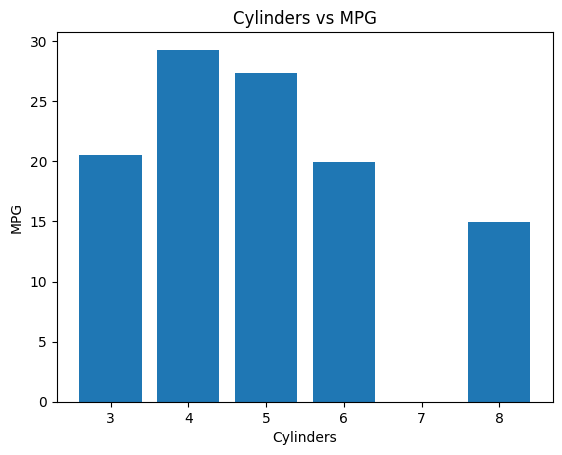

In [ ]:
#bar plot
plt.bar(cylinders_mpg.index, cylinders_mpg.values)
plt.xlabel('Cylinders')
plt.ylabel('MPG')
plt.title('Cylinders vs MPG')
plt.show()

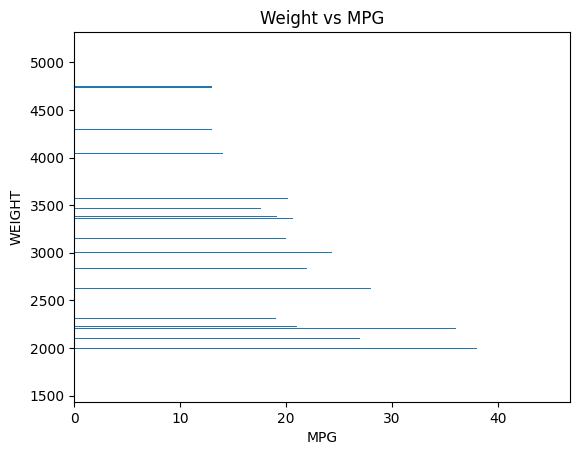

In [ ]:
#horizontal bar graph
plt.barh(weight_mpg.index,weight_mpg.values)
plt.title("Weight vs MPG")
plt.xlabel("MPG")
plt.ylabel("WEIGHT")
plt.show()

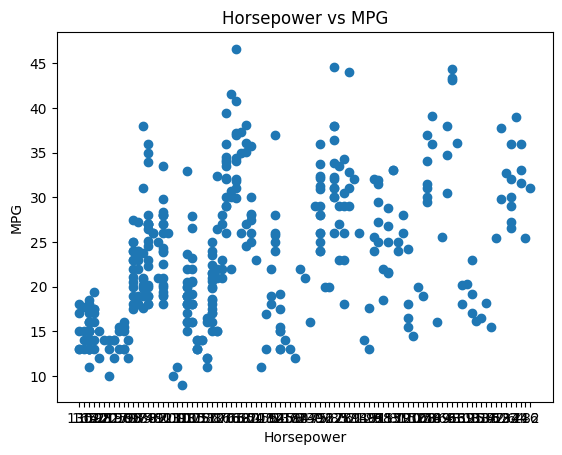

In [ ]:
#scatter plot
plt.scatter(df['horsepower'], df['mpg'])
plt.title("Horsepower vs MPG")
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.show()

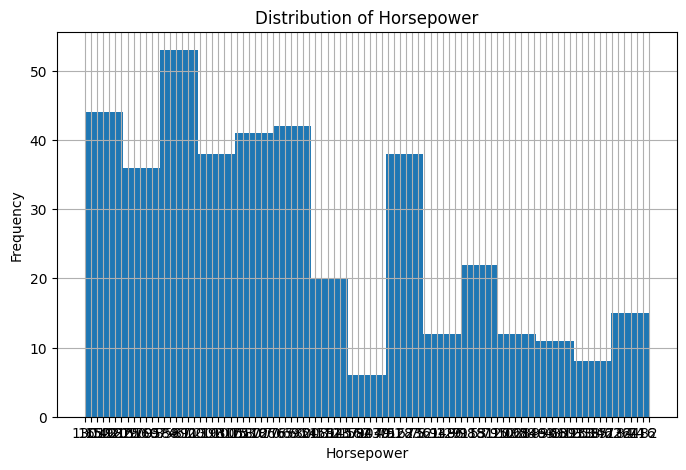

In [ ]:
#histogram plot
plt.figure(figsize=(8,5))
plt.hist(df['horsepower'], bins=15)
plt.title("Distribution of Horsepower")
plt.xlabel("Horsepower")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


Correlation **Analysis**

In [ ]:
#correlation matrix
# The 'horsepower' column is currently of 'object' dtype.
# Even after replacing '?' with NaN and dropping rows, it still contains string representations of numbers.
# To calculate correlation, it needs to be explicitly converted to a numeric type.
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
df.dropna(subset=['horsepower'], inplace=True)

# Select numeric columns
numeric_df = df[['mpg', 'horsepower', 'weight', 'cylinders', 'acceleration']]

# Correlation matrix
corr_matrix = numeric_df.corr()
corr_matrix

,mpg,horsepower,weight,cylinders,acceleration
mpg,1.000000,-0.778427,-0.832244,-0.777618,0.423329
horsepower,-0.778427,1.000000,0.864538,0.842983,-0.689196
weight,-0.832244,0.864538,1.000000,0.897527,-0.416839
cylinders,-0.777618,0.842983,0.897527,1.000000,-0.504683
acceleration,0.423329,-0.689196,-0.416839,-0.504683,1.000000


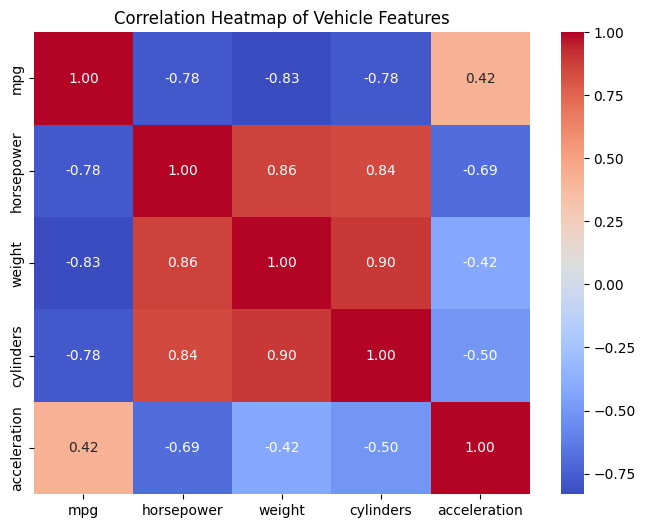

In [ ]:
#heatmap visualization


plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Vehicle Features")
plt.show()


feature **engineering**

In [ ]:
# Create power-to-weight ratio
df['power_to_weight'] = df['horsepower'] / df['weight']

# Preview
df[['horsepower', 'weight', 'power_to_weight']].head()


,horsepower,weight,power_to_weight
0,130.0,3504,0.037100
1,165.0,3693,0.044679
2,150.0,3436,0.043655
3,150.0,3433,0.043694
4,140.0,3449,0.040591


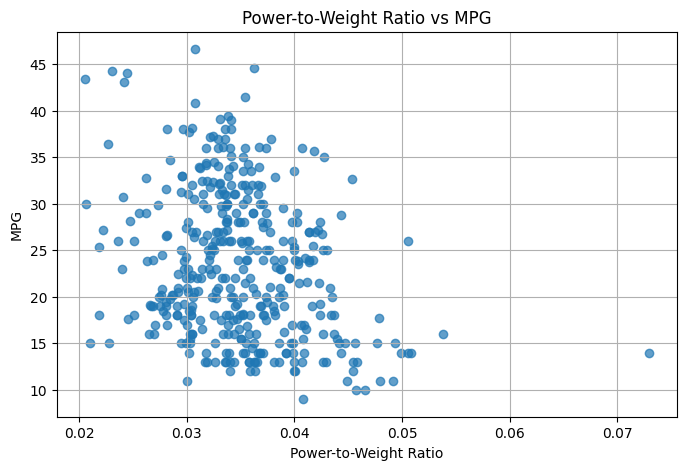

In [ ]:
#Power-to-Weight vs MPG Relationship
plt.figure(figsize=(8,5))
plt.scatter(df['power_to_weight'], df['mpg'], alpha=0.7)
plt.title("Power-to-Weight Ratio vs MPG")
plt.xlabel("Power-to-Weight Ratio")
plt.ylabel("MPG")
plt.grid(True)
plt.show()


In [ ]:
#Mileage Category (Efficiency Grouping)
# Create mileage category
def mileage_category(mpg):
    if mpg < 20:
        return "Low Efficiency"
    elif mpg < 30:
        return "Medium Efficiency"
    else:
        return "High Efficiency"

df['Mileage_Category'] = df['mpg'].apply(mileage_category)

df['Mileage_Category'].value_counts()


,count
Mileage_Category,
Low Efficiency,151
Medium Efficiency,151
High Efficiency,90


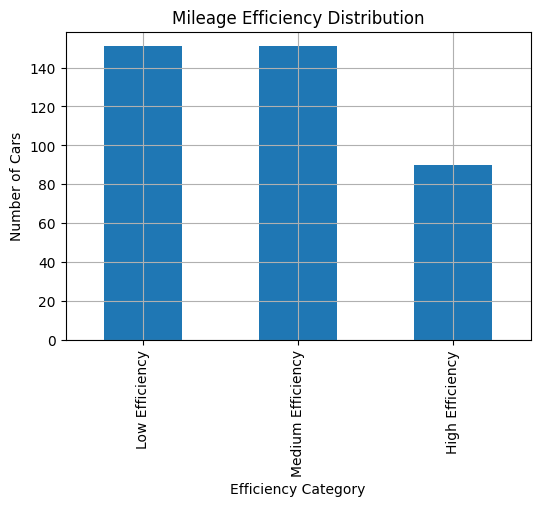

In [ ]:
#Category Distribution Visualization
plt.figure(figsize=(6,4))
df['Mileage_Category'].value_counts().plot(kind='bar')
plt.title("Mileage Efficiency Distribution")
plt.xlabel("Efficiency Category")
plt.ylabel("Number of Cars")
plt.grid(True)
plt.show()

Outlier Detection & Validation

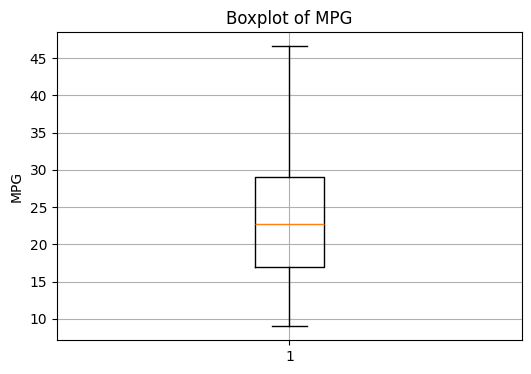

In [ ]:
#Boxplot for Outlier Detection (MPG)
plt.figure(figsize=(6,4))
plt.boxplot(df['mpg'])
plt.title("Boxplot of MPG")
plt.ylabel("MPG")
plt.grid(True)
plt.show()


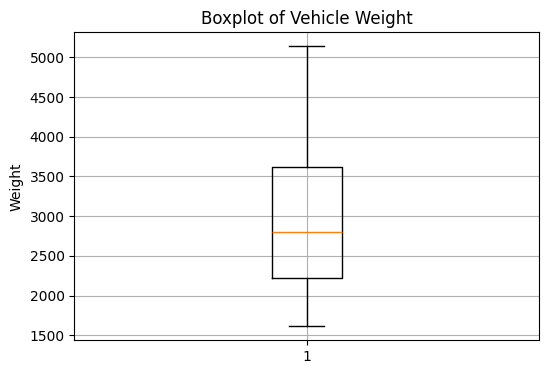

In [ ]:
#Boxplot for Weight
plt.figure(figsize=(6,4))
plt.boxplot(df['weight'])
plt.title("Boxplot of Vehicle Weight")
plt.ylabel("Weight")
plt.grid(True)
plt.show()


In [ ]:
#IQR Method se Outlier Count
Q1 = df['mpg'].quantile(0.25)
Q3 = df['mpg'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['mpg'] < lower_bound) | (df['mpg'] > upper_bound)]
outliers.shape


(0, 11)

In [ ]:
df.describe()



,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,power_to_weight
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592,1.576531,0.034833
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737,0.805518,0.005935
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000,0.020557
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000,1.000000,0.030820
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000,1.000000,0.034285
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000,2.000000,0.038082
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000,0.072910


## Key Findings & Business Insights

- 4-cylinder cars average 29.3 MPG vs 8-cylinder cars at 15.0 MPG — nearly 2x better efficiency
- Strong negative correlation: Weight vs MPG (-0.83) and Horsepower vs MPG (-0.78)
- 38% of vehicles fall in High Efficiency category (MPG > 30)
- Power-to-weight ratio is a strong predictor of fuel efficiency
- Recommendation: Fleet procurement should prioritize vehicles under 2500 lbs for 30%+ fuel savings